In [1]:
import pandas as pd
import matplotlib as plt

happiness = pd.read_csv("DataSets/2018-2019+Happiness.csv")
airbnb = pd.read_csv("DataSets/airbnb.csv")
sales = pd.read_csv("DataSets/web_sales.csv")
salaries = pd.read_csv("DataSets/salaries.csv")
eth = pd.read_csv("DataSets/Ethereum+Historical+Data.csv", index_col = 0)

## Convirtiendo a DateTime

In [2]:
eth.sort_index()

,Coin,Price,Open,High,Low,Vol.,Change %
Date,,,,,,,
1/01/2020,ETH,130.75,129.21,132.97,128.81,10.35M,1.19%
1/01/2021,ETH,729.12,735.87,748.96,715.74,1.64M,-0.93%
1/01/2022,ETH,3765.67,3677.69,3775.20,3675.75,239.54K,2.39%
1/01/2023,ETH,1200.52,1195.69,1204.12,1191.67,126.62K,0.41%
1/01/2024,ETH,2352.03,2281.89,2352.03,2266.75,229.28K,3.07%
...,...,...,...,...,...,...,...
9/11/2023,ETH,2120.16,1888.42,2131.31,1882.91,1.21M,12.22%
9/12/2020,ETH,573.21,554.95,577.94,530.88,9.10M,3.27%
9/12/2021,ETH,4107.69,4435.74,4482.89,4078.14,642.17K,-7.40%


**Para cambiar el formato a datetime, usaremos la funcion pd.to_datetime()**<br><br>

***Por ejemplo:***

In [3]:
eth.index = pd.to_datetime(eth.index, format ='%d/%m/%Y') #es importante especificar el formato, ya que de lo contrario dara error

**Podemos consultar la lista de formatos en la siguiente pagina:** https://docs.python.org/3/library/datetime.html

In [4]:
eth

,Coin,Price,Open,High,Low,Vol.,Change %
Date,,,,,,,
2024-02-10,ETH,2508.31,2486.24,2514.83,2483.50,504.80K,0.89%
2024-02-09,ETH,2486.24,2419.56,2522.96,2419.16,540.92K,2.76%
2024-02-08,ETH,2419.56,2424.66,2461.00,2412.01,350.33K,-0.21%
2024-02-07,ETH,2424.64,2372.65,2443.71,2354.46,355.40K,2.19%
2024-02-06,ETH,2372.65,2301.83,2390.53,2299.24,381.23K,3.08%
...,...,...,...,...,...,...,...
2020-01-05,ETH,135.59,134.32,138.33,134.32,12.19M,0.94%
2020-01-04,ETH,134.33,134.30,135.57,132.76,11.16M,0.04%
2020-01-03,ETH,134.27,127.19,134.86,126.05,15.67M,5.56%


**Si ahora consultamos el index, podemos ver que se cambio el formato de la columna por datetime**

In [5]:
eth.index

DatetimeIndex(['2024-02-10', '2024-02-09', '2024-02-08', '2024-02-07',
               '2024-02-06', '2024-02-05', '2024-02-04', '2024-02-03',
               '2024-02-02', '2024-02-01',
               ...
               '2020-01-10', '2020-01-09', '2020-01-08', '2020-01-07',
               '2020-01-06', '2020-01-05', '2020-01-04', '2020-01-03',
               '2020-01-02', '2020-01-01'],
              dtype='datetime64[ns]', name='Date', length=1502, freq=None)

In [6]:
eth.sort_index()

,Coin,Price,Open,High,Low,Vol.,Change %
Date,,,,,,,
2020-01-01,ETH,130.75,129.21,132.97,128.81,10.35M,1.19%
2020-01-02,ETH,127.19,130.75,130.77,126.74,11.45M,-2.72%
2020-01-03,ETH,134.27,127.19,134.86,126.05,15.67M,5.56%
2020-01-04,ETH,134.33,134.30,135.57,132.76,11.16M,0.04%
2020-01-05,ETH,135.59,134.32,138.33,134.32,12.19M,0.94%
...,...,...,...,...,...,...,...
2024-02-06,ETH,2372.65,2301.83,2390.53,2299.24,381.23K,3.08%
2024-02-07,ETH,2424.64,2372.65,2443.71,2354.46,355.40K,2.19%
2024-02-08,ETH,2419.56,2424.66,2461.00,2412.01,350.33K,-0.21%


## Reemplazar valores en un DataFrame

Para cambiar un valor podemos usar el metodo replace

In [53]:
eth['Change %'] = eth['Change %'].replace('%','', regex = True) 
# si no se le da el parametro Regex en true, no quitara el porcentaje
# regex en true, sirve para decirle a pandas "encuentra cualquier cosa que se parezca a esto", en false, buscara coincidencias exactas

In [8]:
eth

,Coin,Price,Open,High,Low,Vol.,Change %
Date,,,,,,,
2024-02-10,ETH,2508.31,2486.24,2514.83,2483.50,504.80K,0.89
2024-02-09,ETH,2486.24,2419.56,2522.96,2419.16,540.92K,2.76
2024-02-08,ETH,2419.56,2424.66,2461.00,2412.01,350.33K,-0.21
2024-02-07,ETH,2424.64,2372.65,2443.71,2354.46,355.40K,2.19
2024-02-06,ETH,2372.65,2301.83,2390.53,2299.24,381.23K,3.08
...,...,...,...,...,...,...,...
2020-01-05,ETH,135.59,134.32,138.33,134.32,12.19M,0.94
2020-01-04,ETH,134.33,134.30,135.57,132.76,11.16M,0.04
2020-01-03,ETH,134.27,127.19,134.86,126.05,15.67M,5.56


**Nota: Se pueden reemplazar varios al mismo tiempo, para ello dentro del parentesis del replace hay que poner corchetes con la lista de valores a cambiar y se deben poner respectivamente los valores que reemplazaran los valores especificados**

## Conversion de tipos de dato, usando "astype"

In [9]:
eth.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1502 entries, 2024-02-10 to 2020-01-01
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Coin      1502 non-null   object 
 1   Price     1502 non-null   float64
 2   Open      1502 non-null   float64
 3   High      1502 non-null   float64
 4   Low       1502 non-null   float64
 5   Vol.      1502 non-null   object 
 6   Change %  1502 non-null   object 
dtypes: float64(4), object(3)
memory usage: 93.9+ KB


In [10]:
eth['Change %'].max() 

'9.85'

*Como podemos ver, si preguntamos el valor maximo, no nos da error pero, sabemos que el valor maximo no es 9.85, por lo que esta incorrecto, esto se debe a que Change es un dato tipo objeto, no un float, por lo que el "programa" no sabe realmente cual es el valor mas alto.*

In [11]:
eth.drop(columns = ['Coin'], inplace = True) #Paso extra propio por que la columna coin me parece una estupidez xD,sigue mas abajo la conversion

In [12]:
eth.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1502 entries, 2024-02-10 to 2020-01-01
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Price     1502 non-null   float64
 1   Open      1502 non-null   float64
 2   High      1502 non-null   float64
 3   Low       1502 non-null   float64
 4   Vol.      1502 non-null   object 
 5   Change %  1502 non-null   object 
dtypes: float64(4), object(2)
memory usage: 82.1+ KB


In [13]:
eth['Change %'] = eth['Change %'].astype('float') #astype() puede converti tipos de datos, para ello debes especificar el tipo entre comillas simples

In [14]:
eth

,Price,Open,High,Low,Vol.,Change %
Date,,,,,,
2024-02-10,2508.31,2486.24,2514.83,2483.50,504.80K,0.89
2024-02-09,2486.24,2419.56,2522.96,2419.16,540.92K,2.76
2024-02-08,2419.56,2424.66,2461.00,2412.01,350.33K,-0.21
2024-02-07,2424.64,2372.65,2443.71,2354.46,355.40K,2.19
2024-02-06,2372.65,2301.83,2390.53,2299.24,381.23K,3.08
...,...,...,...,...,...,...
2020-01-05,135.59,134.32,138.33,134.32,12.19M,0.94
2020-01-04,134.33,134.30,135.57,132.76,11.16M,0.04
2020-01-03,134.27,127.19,134.86,126.05,15.67M,5.56


In [15]:
eth['Change %'].max()

25.96

*Esta vez, como podemos evidenciar, el resultado es distinto y esta correcto, esto gracias a que al ser un float ahora si se puede identificar cual es el valor mas alto.*

**Dato extra: Si hubieramnos convertido el dato a tipo Int, el codigo hubiera truncado el valor al entero del dato**

## Extrayendo componentes de una fecha con dt

In [16]:
sales

,ProductKey,product,product_subcategory,OrderDateKey,CalendarYear,SalesTerritoryRegion,SalesTerritoryCountry,SalesOrderNumber,SalesAmount,TaxAmt,Freight
0,310,"Road-150 Red, 62",Road Bikes,20101229,2010,Canada,Canada,SO43697,3578.2700,286.2616,89.4568
1,346,"Mountain-100 Silver, 44",Mountain Bikes,20101229,2010,France,France,SO43698,3399.9900,271.9992,84.9998
2,346,"Mountain-100 Silver, 44",Mountain Bikes,20101229,2010,Northwest,United States,SO43699,3399.9900,271.9992,84.9998
3,336,"Road-650 Black, 62",Road Bikes,20101229,2010,Southwest,United States,SO43700,699.0982,55.9279,17.4775
4,346,"Mountain-100 Silver, 44",Mountain Bikes,20101229,2010,Australia,Australia,SO43701,3399.9900,271.9992,84.9998
...,...,...,...,...,...,...,...,...,...,...,...
60393,485,Fender Set - Mountain,Fenders,20140128,2014,Canada,Canada,SO75122,21.9800,1.7584,0.5495
60394,225,AWC Logo Cap,Caps,20140128,2014,Canada,Canada,SO75122,8.9900,0.7192,0.2248
60395,485,Fender Set - Mountain,Fenders,20140128,2014,Canada,Canada,SO75123,21.9800,1.7584,0.5495
60396,486,All-Purpose Bike Stand,Bike Stands,20140128,2014,Canada,Canada,SO75123,159.0000,12.7200,3.9750


In [17]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60398 entries, 0 to 60397
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ProductKey             60398 non-null  int64  
 1   product                60398 non-null  object 
 2   product_subcategory    60398 non-null  object 
 3   OrderDateKey           60398 non-null  int64  
 4   CalendarYear           60398 non-null  int64  
 5   SalesTerritoryRegion   60398 non-null  object 
 6   SalesTerritoryCountry  60398 non-null  object 
 7   SalesOrderNumber       60398 non-null  object 
 8   SalesAmount            60398 non-null  float64
 9   TaxAmt                 60398 non-null  float64
 10  Freight                60398 non-null  float64
dtypes: float64(3), int64(3), object(5)
memory usage: 5.1+ MB


In [18]:
sales['OrderDateKey'] = pd.to_datetime(sales['OrderDateKey'], format = '%Y%m%d')

In [19]:
sales

,ProductKey,product,product_subcategory,OrderDateKey,CalendarYear,SalesTerritoryRegion,SalesTerritoryCountry,SalesOrderNumber,SalesAmount,TaxAmt,Freight
0,310,"Road-150 Red, 62",Road Bikes,2010-12-29,2010,Canada,Canada,SO43697,3578.2700,286.2616,89.4568
1,346,"Mountain-100 Silver, 44",Mountain Bikes,2010-12-29,2010,France,France,SO43698,3399.9900,271.9992,84.9998
2,346,"Mountain-100 Silver, 44",Mountain Bikes,2010-12-29,2010,Northwest,United States,SO43699,3399.9900,271.9992,84.9998
3,336,"Road-650 Black, 62",Road Bikes,2010-12-29,2010,Southwest,United States,SO43700,699.0982,55.9279,17.4775
4,346,"Mountain-100 Silver, 44",Mountain Bikes,2010-12-29,2010,Australia,Australia,SO43701,3399.9900,271.9992,84.9998
...,...,...,...,...,...,...,...,...,...,...,...
60393,485,Fender Set - Mountain,Fenders,2014-01-28,2014,Canada,Canada,SO75122,21.9800,1.7584,0.5495
60394,225,AWC Logo Cap,Caps,2014-01-28,2014,Canada,Canada,SO75122,8.9900,0.7192,0.2248
60395,485,Fender Set - Mountain,Fenders,2014-01-28,2014,Canada,Canada,SO75123,21.9800,1.7584,0.5495
60396,486,All-Purpose Bike Stand,Bike Stands,2014-01-28,2014,Canada,Canada,SO75123,159.0000,12.7200,3.9750


In [20]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60398 entries, 0 to 60397
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   ProductKey             60398 non-null  int64         
 1   product                60398 non-null  object        
 2   product_subcategory    60398 non-null  object        
 3   OrderDateKey           60398 non-null  datetime64[ns]
 4   CalendarYear           60398 non-null  int64         
 5   SalesTerritoryRegion   60398 non-null  object        
 6   SalesTerritoryCountry  60398 non-null  object        
 7   SalesOrderNumber       60398 non-null  object        
 8   SalesAmount            60398 non-null  float64       
 9   TaxAmt                 60398 non-null  float64       
 10  Freight                60398 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(5)
memory usage: 5.1+ MB


In [21]:
sales['OrderDateKey'].dt.month

0        12
1        12
2        12
3        12
4        12
         ..
60393     1
60394     1
60395     1
60396     1
60397     1
Name: OrderDateKey, Length: 60398, dtype: int32

In [22]:
sales['month'] = sales['OrderDateKey'].dt.month

In [23]:
sales

,ProductKey,product,product_subcategory,OrderDateKey,CalendarYear,SalesTerritoryRegion,SalesTerritoryCountry,SalesOrderNumber,SalesAmount,TaxAmt,Freight,month
0,310,"Road-150 Red, 62",Road Bikes,2010-12-29,2010,Canada,Canada,SO43697,3578.2700,286.2616,89.4568,12
1,346,"Mountain-100 Silver, 44",Mountain Bikes,2010-12-29,2010,France,France,SO43698,3399.9900,271.9992,84.9998,12
2,346,"Mountain-100 Silver, 44",Mountain Bikes,2010-12-29,2010,Northwest,United States,SO43699,3399.9900,271.9992,84.9998,12
3,336,"Road-650 Black, 62",Road Bikes,2010-12-29,2010,Southwest,United States,SO43700,699.0982,55.9279,17.4775,12
4,346,"Mountain-100 Silver, 44",Mountain Bikes,2010-12-29,2010,Australia,Australia,SO43701,3399.9900,271.9992,84.9998,12
...,...,...,...,...,...,...,...,...,...,...,...,...
60393,485,Fender Set - Mountain,Fenders,2014-01-28,2014,Canada,Canada,SO75122,21.9800,1.7584,0.5495,1
60394,225,AWC Logo Cap,Caps,2014-01-28,2014,Canada,Canada,SO75122,8.9900,0.7192,0.2248,1
60395,485,Fender Set - Mountain,Fenders,2014-01-28,2014,Canada,Canada,SO75123,21.9800,1.7584,0.5495,1
60396,486,All-Purpose Bike Stand,Bike Stands,2014-01-28,2014,Canada,Canada,SO75123,159.0000,12.7200,3.9750,1


***Nota: el metodo anterior se puede usar con dias, meses o años, solo debes cambiar month por day o year, entre otros segun lo que busques*** <br><br>

**Ejemplos:** <br>

sales['OrderDateKey'].dt.month da el mes<br>
sales['OrderDateKey'].dt.day da el dia<br>
sales['OrderDateKey'].dt.year da el año<br>

## Agrupando datos con Groupby

Si quisieramos obtener el promedio de ventas por año necesitariamos utilizar el metodo groupby, ya que el metodo mean, no puede hacer esta operacion por si solo, mean puede sacar promedio, pero no agrupar los resultados, ya que por si solo sacaria el promedio de todos los registros sin separarlos por año. 

Por ejemplo:

In [24]:
sales.groupby('CalendarYear')['SalesAmount'].mean()

CalendarYear
2010    3101.502600
2011    3192.926863
2012    1719.895553
2013     309.682588
2014      23.195289
Name: SalesAmount, dtype: float64

Otro Ejemplo:

In [25]:
salaries.groupby('job_title')['salary_in_usd'].max().sort_values(ascending = False) 
#Esto mostraria el salario mas alto de cada area y lo ordenaria en orden descendente
#Nota: van en ese orden los metodos por logica, primero agrupas, luego identificas el maximo sueldo del grupo y finalmente ordenas los resultados

job_title
Business Intelligence Consultant        615201
Research Scientist                      450000
Data Analyst                            430967
Analytics Engineer                      430640
Applied Machine Learning Scientist      423000
                                         ...  
Machine Learning Operations Engineer     60000
BI Data Engineer                         60000
Data DevOps Engineer                     53984
Insight Analyst                          53984
Principal Data Architect                 38154
Name: salary_in_usd, Length: 124, dtype: int64

**Podemos tambien agrupar por varios filtro, esto dejando entre corchetes "[ ]" y poniendo entre comillas simples los nombres de las columnas que usaremos**<br>

***Por ejemplo:***

In [26]:
salaries.groupby(['job_title', 'experience_level'])['salary_in_usd'].max().sort_values(ascending = False) 

job_title                           experience_level
Business Intelligence Consultant    EN                  615201
Research Scientist                  MI                  450000
Data Analyst                        MI                  430967
Analytics Engineer                  MI                  430640
Applied Machine Learning Scientist  MI                  423000
                                                         ...  
AI Engineer                         EN                   35000
Head of Data                        MI                   31520
Data Quality Engineer               EN                   23753
Data Analytics Engineer             EN                   20000
Staff Data Analyst                  EX                   15000
Name: salary_in_usd, Length: 259, dtype: int64

## Metodo Agg

**Sirve para aplicar una o varias funciones de agregación a un DataFrame o a un groupby.**<br>

***Por ejemplo:***

In [28]:
salaries.groupby('job_title')['salary_in_usd'].agg(['mean', 'max','min'])

,mean,max,min
job_title,,,
AI Architect,250328.000000,330000,146900
AI Developer,139916.705882,275000,50000
AI Engineer,175116.225806,372000,21593
AI Programmer,67382.333333,120000,40000
AI Research Engineer,63481.600000,150000,24322
...,...,...,...
Sales Data Analyst,60000.000000,60000,60000
Software Data Engineer,111627.666667,210000,50000
Staff Data Analyst,79917.000000,179998,15000


Como se puede ver en la celda anterior, usamos el metodo agg para mostrar el promedio, valor minimo y maximo en un solo resultado (en 1 columna), agrupando la informacion por el nombre del trabajo.<br>
Podemos tambien ordenar los resultados con el metodo sort_values. <br>
***Por ejemplo:***

In [29]:
salaries.groupby('job_title')['salary_in_usd'].agg(['mean', 'max','min']).sort_values(by = 'mean', ascending = False)

,mean,max,min
job_title,,,
Business Intelligence Consultant,615201.000,615201,615201
Analytics Engineering Manager,399880.000,399880,399880
Data Science Tech Lead,375000.000,375000,375000
Managing Director Data Science,300000.000,300000,300000
AWS Data Architect,258000.000,258000,258000
...,...,...,...
Machine Learning Specialist,55000.000,70000,40000
Data DevOps Engineer,53984.000,53984,53984
Insight Analyst,47673.875,53984,43064


**Si quisieramos poner todo en distintas columnas, tendriamos que crear variables con los datos que queremos dento del parentesis del .agg** <br>
***Por ejemplo:***

In [35]:
salaries.groupby('job_title').agg(
    avg_salary=('salary_in_usd', 'mean'),
    max_salary=('salary_in_usd', 'max'),
    min_salary=('salary_in_usd', 'min')
)

,avg_salary,max_salary,min_salary
job_title,,,
AI Architect,250328.000000,330000,146900
AI Developer,139916.705882,275000,50000
AI Engineer,175116.225806,372000,21593
AI Programmer,67382.333333,120000,40000
AI Research Engineer,63481.600000,150000,24322
...,...,...,...
Sales Data Analyst,60000.000000,60000,60000
Software Data Engineer,111627.666667,210000,50000
Staff Data Analyst,79917.000000,179998,15000


***Otro Ejemplo (el del curso):***

In [36]:
salaries.groupby('job_title').agg(
    {'salary_in_usd':['mean','max','min'],
    'remote_ratio':['mean']}
)

salary_in_usd                 remote_ratio
                                          mean     max     min         mean
job_title                                                                  
AI Architect                     250328.000000  330000  146900    33.333333
AI Developer                     139916.705882  275000   50000    41.176471
AI Engineer                      175116.225806  372000   21593    30.645161
AI Programmer                     67382.333333  120000   40000    50.000000
AI Research Engineer              63481.600000  150000   24322    80.000000
...                                        ...     ...     ...          ...
Sales Data Analyst                60000.000000   60000   60000     0.000000
Software Data Engineer           111627.666667  210000   50000    83.333333
Staff Data Analyst                79917.000000  179998   15000    50.000000
Staff Data Scientist             134500.000000  164000  105000    75.000000
Staff Machine Learning Engineer  185000.000000  185000  185000    50.000000

[124 rows x 4 columns]

Como se puede ver en el resultado anterior todos los calculos que hicimos para salary_in_usd estan en una columna, y el nuevo calculo del promedio que hicimos para el remote_ratio queda en otra columna

## Reshaping DataFrames with Stack and Unstack

Digamos que queremos ver cada año de trabajo, los niveles de experiencia y el sueldo promedio por nivel de experiencia y año de trabajo

In [39]:
salaries.groupby(['work_year','experience_level'])['salary_in_usd'].mean()

work_year  experience_level
2020       EN                   69840.666667
           EX                  179958.250000
           MI                   91870.935484
           SE                  138648.894737
2021       EN                   63463.065217
           EX                  186128.000000
           MI                   86818.390805
           SE                  125989.746667
2022       EN                   80018.698276
           EX                  188260.292683
           MI                  102733.432961
           SE                  148059.962148
2023       EN                   96016.143860
           EX                  189511.070093
           MI                  120579.427548
           SE                  165579.532707
Name: salary_in_usd, dtype: float64

Como podemos ver, nos arrojo los resultados deseados, no obstante, se ve desordenado y puede llegar a ser poco comprensible, por lo que es mejor mostrarlo como si fuera un dataframe, para eso utilizaremos el metodo Unstack de la sieguiente forma:

In [41]:
salaries.groupby(['work_year','experience_level'])['salary_in_usd'].mean().unstack()

experience_level,EN,EX,MI,SE
work_year,,,,
2020,69840.666667,179958.250000,91870.935484,138648.894737
2021,63463.065217,186128.000000,86818.390805,125989.746667
2022,80018.698276,188260.292683,102733.432961,148059.962148
2023,96016.143860,189511.070093,120579.427548,165579.532707


Como podemos ver en la celda anterior, ya se ven mas ordenados los resultados, dejando una fila para cada año y una columna por cada nivel de experiencia.<br><br>
Guardaremos los resultados en una variable ya que nos podria ser de utilidad mas adelante.

In [44]:
work_year_salary_with_experience = salaries.groupby(['work_year','experience_level'])['salary_in_usd'].mean().unstack()

In [45]:
work_year_salary_with_experience

experience_level,EN,EX,MI,SE
work_year,,,,
2020,69840.666667,179958.250000,91870.935484,138648.894737
2021,63463.065217,186128.000000,86818.390805,125989.746667
2022,80018.698276,188260.292683,102733.432961,148059.962148
2023,96016.143860,189511.070093,120579.427548,165579.532707


Si ahora quisieramos volver a ver el resultado como antes (todo apilado), podriamos usar el metodo stack, que es la contraparte de unstack.<br><br>

***Por ejemplo:***

In [46]:
work_year_salary_with_experience.stack()

work_year  experience_level
2020       EN                   69840.666667
           EX                  179958.250000
           MI                   91870.935484
           SE                  138648.894737
2021       EN                   63463.065217
           EX                  186128.000000
           MI                   86818.390805
           SE                  125989.746667
2022       EN                   80018.698276
           EX                  188260.292683
           MI                  102733.432961
           SE                  148059.962148
2023       EN                   96016.143860
           EX                  189511.070093
           MI                  120579.427548
           SE                  165579.532707
dtype: float64

**Vamos a graficar ahora los resultados anteriores para recordar como se hacia**

In [47]:
work_year_salary_with_experience

experience_level,EN,EX,MI,SE
work_year,,,,
2020,69840.666667,179958.250000,91870.935484,138648.894737
2021,63463.065217,186128.000000,86818.390805,125989.746667
2022,80018.698276,188260.292683,102733.432961,148059.962148
2023,96016.143860,189511.070093,120579.427548,165579.532707


<Axes: xlabel='work_year'>

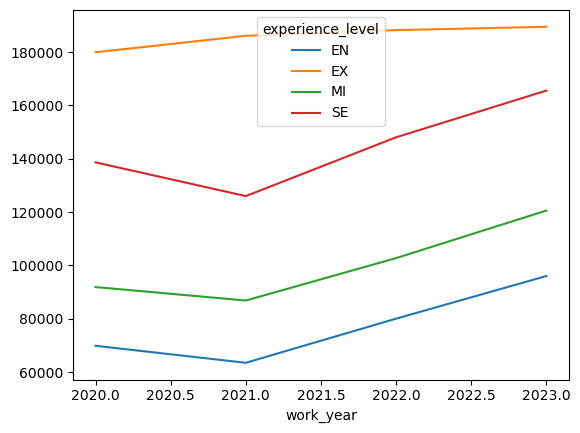

In [48]:
work_year_salary_with_experience.plot()

**Como podemos comprobar nos muestra un grafico bastante claro, pero que pasa si agregamos el metodo stack?**

<Axes: xlabel='work_year,experience_level'>

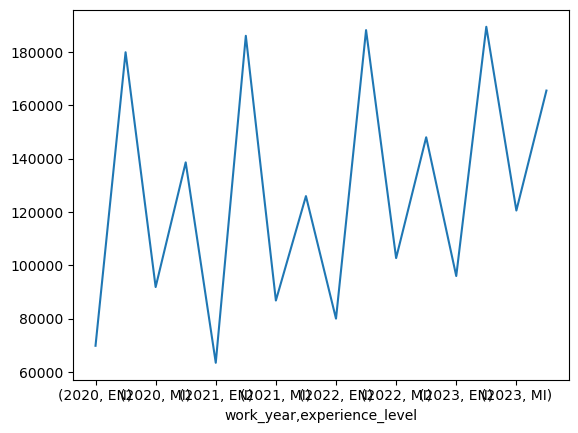

In [49]:
work_year_salary_with_experience.stack().plot()

Podemos ver un resultado muy distinto al interior y es que por lo vitsto, pandas trato de acomodar los resultados en una sola linea, agregando en el eje x un valor por cada año + nivel de experiencia (por ejemplo: 2020,EN es un valor en el eje x y 2022,Mi es otro valor del eje x)

**Como aprendimos anteriormente, podemos cambiar tambien el tipo de grafico con el parametro kind dentro del metodo plot**<br><br>

***Por ejemplo; Un grafico de barras***

<Axes: xlabel='work_year'>

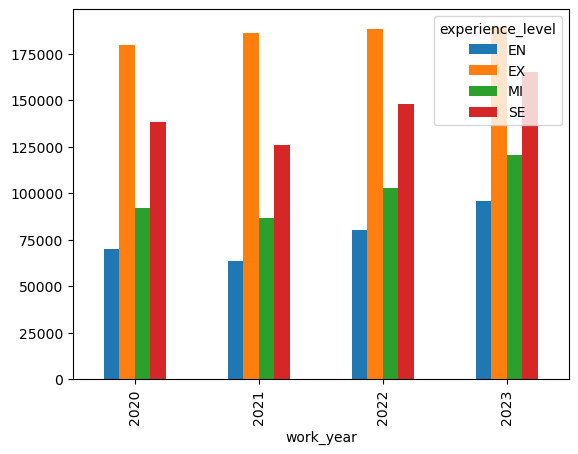

In [51]:
work_year_salary_with_experience.plot(kind = 'bar')

**Como podemos ver, ya nos dio el grafico que queriamosm, pero el detalle nos tapa el 2023, lo que podemos areglar dandole al metodo plot, el parametro figsize, que nos permite modificar el tamaño del grafico**

<Axes: xlabel='work_year'>

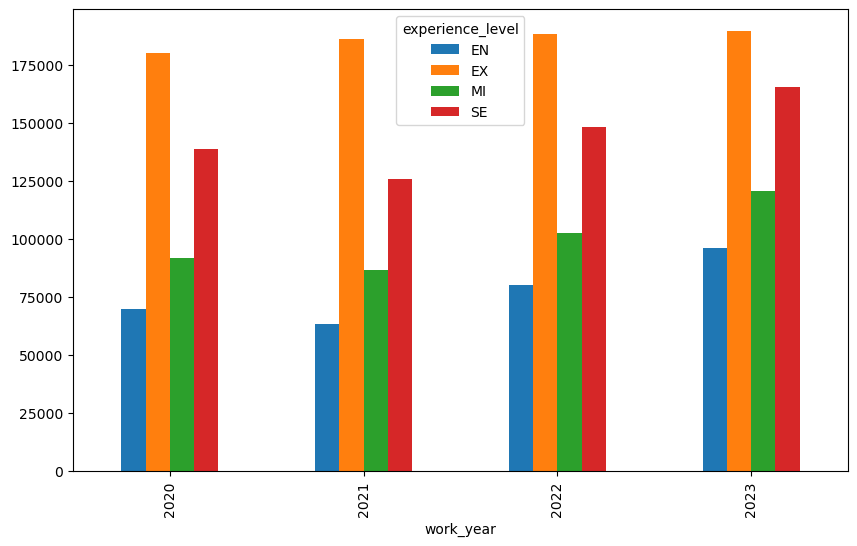

In [52]:
work_year_salary_with_experience.plot(kind = 'bar', figsize = (10,6))

Al usar figsize, podemos ver que nos agrando el grafico y movio el detalle al centro, lo que ya nos permite ver mucho mejor el grafico